In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

In [17]:
# Colunas que serão usadas para o estudo
# columns = [
#     'make',
#     'model',
#     'variant',
#     'yearFrom',
#     'yearTo',
#     'bodyType',
#     'doors',
#     'seats',
#     'engineFuelType',
#     'enginePowerBhp',
#     'gearboxType',
#     'gears',
#     'drivetrain',
#     'topSpeedKph',
#     'fuelTankLitres'
# ]
# Visualizando dados
df = pd.read_csv(fr".\data\ford-specifications.csv")
print(df.columns)
print(df.head())
print(df.info())
print(df.describe)

Index(['make', 'model', 'variant', 'yearFrom', 'yearTo', 'bodyType', 'doors',
       'seats', 'engineCode', 'engineDisplacement', 'engineCylinders',
       'engineValves', 'engineFuelType', 'enginePowerBhp', 'enginePowerKw',
       'engineTorqueNm', 'engineAspiration', 'enginePosition', 'gearboxType',
       'gears', 'drivetrain', 'acceleration0100', 'topSpeedKph', 'topSpeedMph',
       'fuelEconomyCombinedMpg', 'fuelEconomyCombinedL100',
       'fuelEconomyUrbanL100', 'fuelEconomyExtraUrbanL100', 'fuelTankLitres',
       'co2Gkm', 'emissionsStandard', 'noxMgkm', 'lengthMm', 'widthMm',
       'heightMm', 'wheelbaseMm', 'weightKg', 'grossWeightKg', 'bootLitres',
       'bootLitresMax', 'tyreFront', 'tyreRear', 'brakeFront', 'brakeRear',
       'batteryKwh', 'electricRangeKm', 'chargingKw'],
      dtype='object')
   make            model                           variant  yearFrom  yearTo  \
0  FORD  2010Ford Taurus      3.5L V6 Duratec 6AT (263 HP)       NaN     NaN   
1  FORD  2010Ford

In [ ]:
# Ver as dispersões dos dados aqui, se eu passar a média com eles sendo muito dispersos isso pode causar uma generalização ruim.
# Ver quantos dados são nulos 
# print(df.isnull().sum().sort_values(ascending=True))
media_nulls = df.isnull().mean() * 100
cols_drop = media_nulls[media_nulls > 80].index
df.drop(columns=cols_drop, inplace=True)
print(df.head())
print(df.describe)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   make                       1498 non-null   object 
 1   model                      1498 non-null   object 
 2   variant                    1498 non-null   object 
 3   yearFrom                   1492 non-null   float64
 4   yearTo                     1195 non-null   float64
 5   engineDisplacement         1454 non-null   float64
 6   engineCylinders            1488 non-null   float64
 7   engineFuelType             1472 non-null   object 
 8   enginePowerBhp             1461 non-null   float64
 9   enginePowerKw              1461 non-null   float64
 10  engineTorqueNm             1440 non-null   float64
 11  gearboxType                1475 non-null   object 
 12  gears                      1410 non-null   float64
 13  drivetrain                 1272 non-null   objec

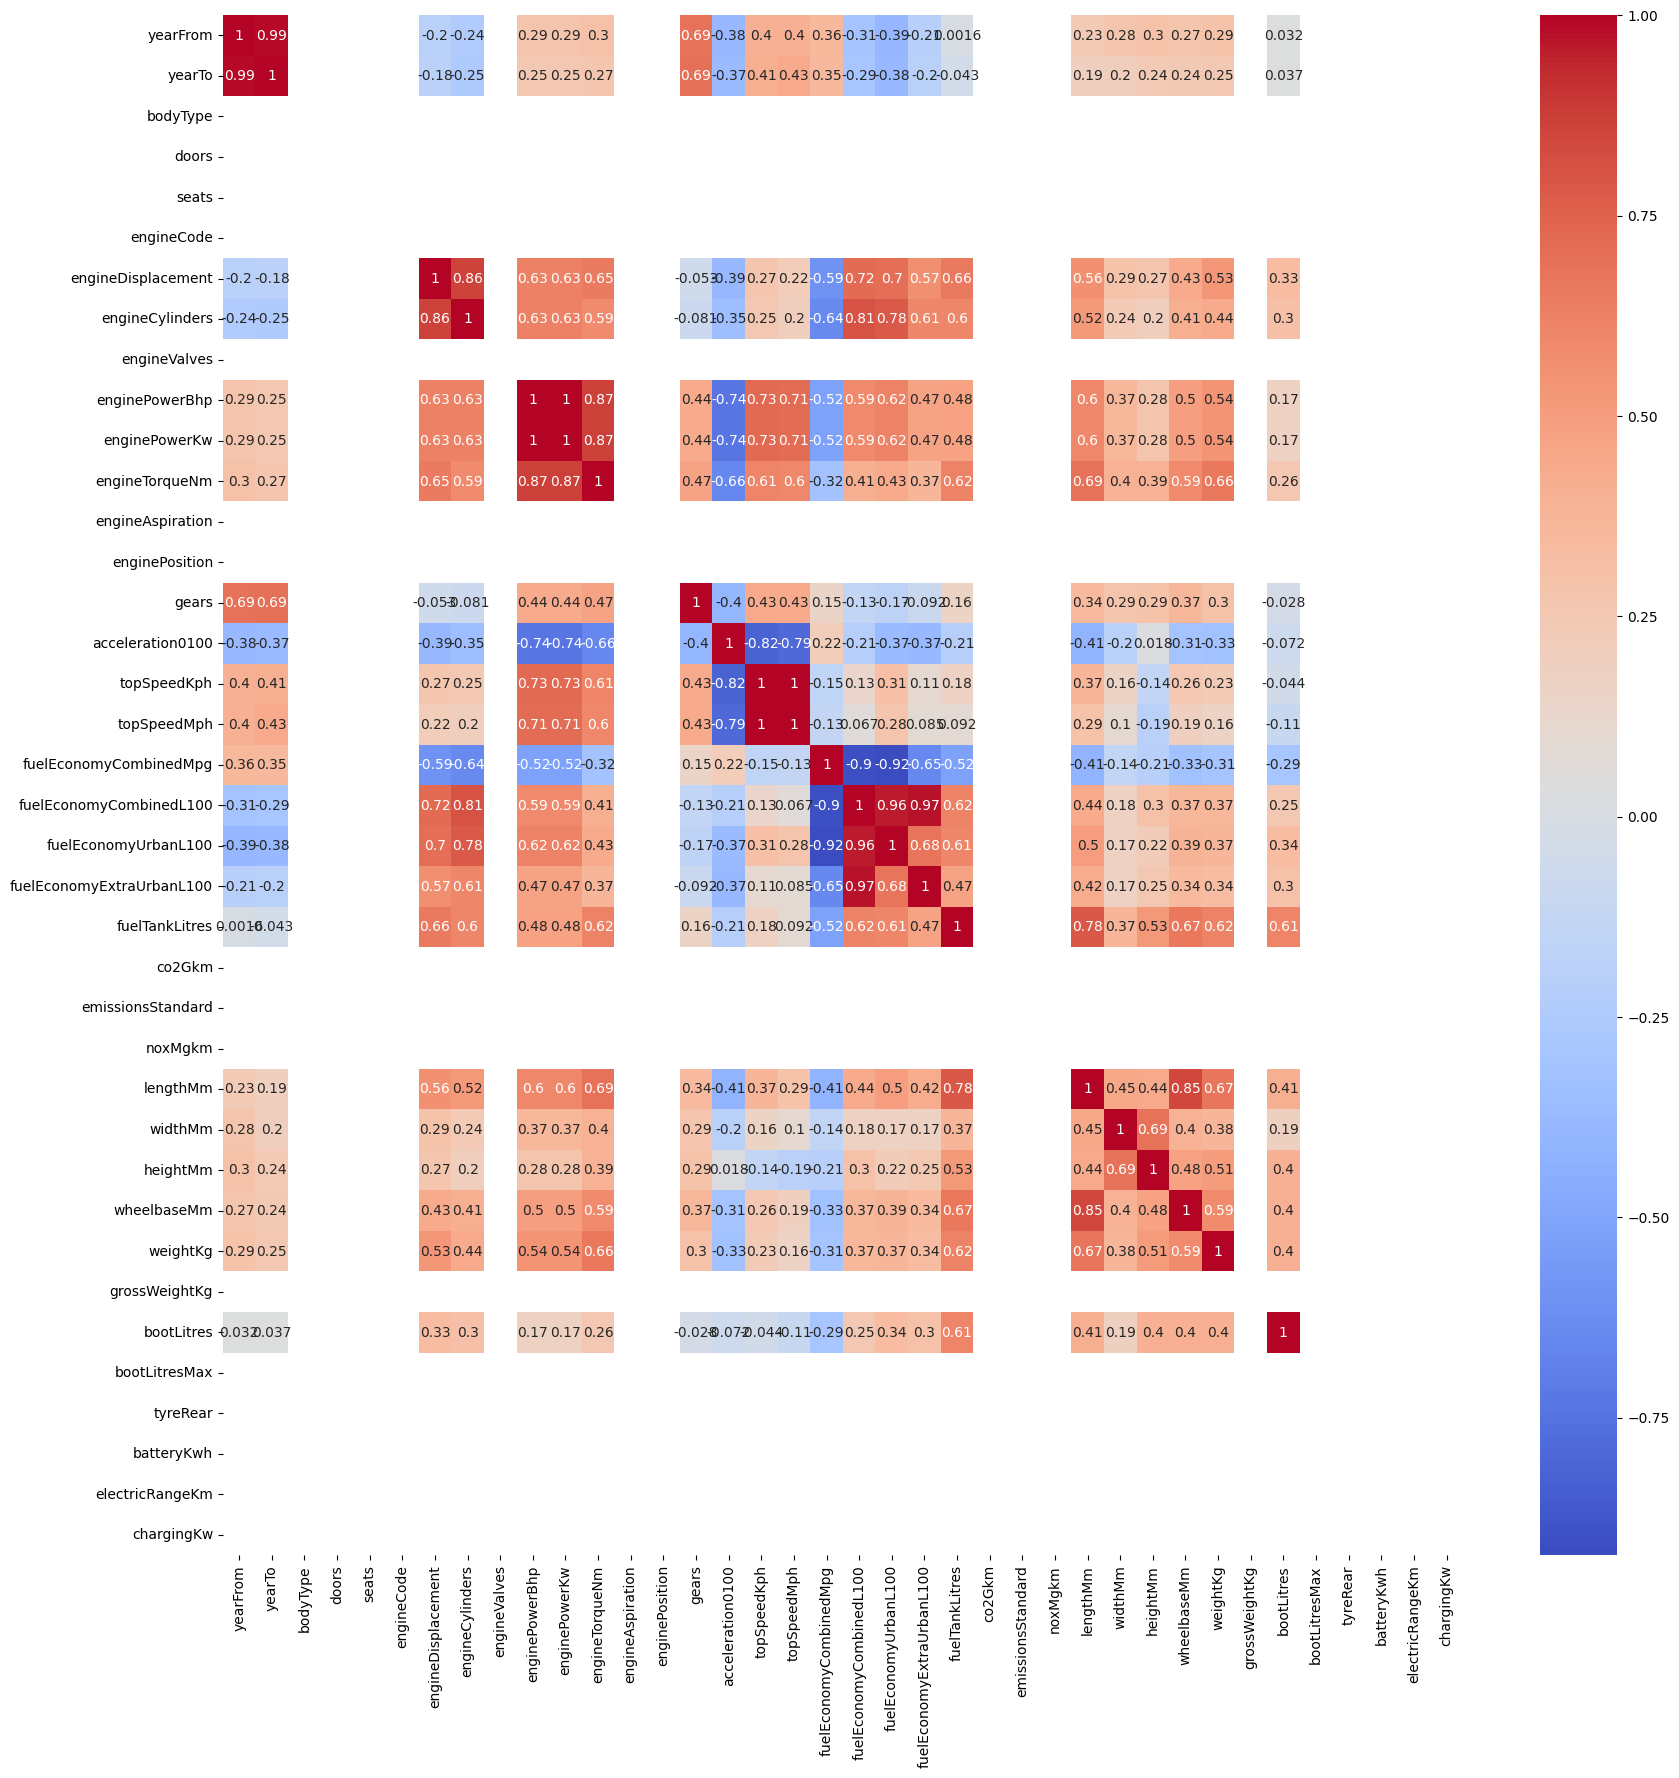

In [ ]:
# Vendo quais colunas e importante para o estudo
num_cols = df.select_dtypes(np.number)
columns = [num_cols.columns]

plt.figure(figsize=(20, 20))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.show()